In [1]:
import logging
from pathlib import Path
from typing import Tuple

import matplotlib
import matplotlib.pyplot as plt
from pydantic import Field
from pydantic_settings import BaseSettings, CliSettingsSource, PydanticBaseSettingsSource

from ehc_sn.data.datasets import MazeDataset
from ehc_sn.data.index import filter_index, read_index
from ehc_sn.figures.modules.dataset import plot
from ehc_sn import data
from ehc_sn import figures

In [2]:
! python scripts/data-gen/build-mazehard.py --help

                                                                                
 Usage: build-mazehard.py [OPTIONS]                                             
                                                                                
 Download mazes from HuggingFace, save raw CSVs, and build per-channel .npy     
 files + JSONL index.                                                           
                                                                                
╭─ Options ────────────────────────────────────────────────────────────────────╮
│ --raw-dir                   PATH  Directory to store downloaded raw CSV      │
│                                   files.                                     │
│                                   [default: data/raw/maze-30x30-hard-1k]     │
│ --out-dir                   PATH  Output directory for processed data.       │
│                                   [default:                                  │
│                           

In [3]:
! python scripts/data-gen/build-mazehard.py

Removed existing index: data/processed/maze-30x30-hard-1k/index.jsonl
  → Raw CSV saved to data/raw/maze-30x30-hard-1k/train.csv
Processing split 'train' …
  → 1000 mazes written (total so far: 1000)
  → Raw CSV saved to data/raw/maze-30x30-hard-1k/test.csv
Processing split 'test' …
  → 1000 mazes written (total so far: 2000)

Done. Index written to data/processed/maze-30x30-hard-1k/index.jsonl


In [4]:
data_path = Path("data/processed/maze-30x30-hard-1k")

In [5]:
entries = read_index(data_path / "index.jsonl")
entries = filter_index(entries, split="test")
entries

[MazeIndexEntry(id='1000', source='sapientinc/maze-30x30-hard-1k', split='test', shape=(30, 30), channels=['topology', 'start', 'goals', 'solution'], n_observations=0, n_goals=1, difficulty='112'),
 MazeIndexEntry(id='1001', source='sapientinc/maze-30x30-hard-1k', split='test', shape=(30, 30), channels=['topology', 'start', 'goals', 'solution'], n_observations=0, n_goals=1, difficulty='119'),
 MazeIndexEntry(id='1002', source='sapientinc/maze-30x30-hard-1k', split='test', shape=(30, 30), channels=['topology', 'start', 'goals', 'solution'], n_observations=0, n_goals=1, difficulty='110'),
 MazeIndexEntry(id='1003', source='sapientinc/maze-30x30-hard-1k', split='test', shape=(30, 30), channels=['topology', 'start', 'goals', 'solution'], n_observations=0, n_goals=1, difficulty='120'),
 MazeIndexEntry(id='1004', source='sapientinc/maze-30x30-hard-1k', split='test', shape=(30, 30), channels=['topology', 'start', 'goals', 'solution'], n_observations=0, n_goals=1, difficulty='116'),
 MazeIndex

In [6]:
ds = MazeDataset(entries, data_path / "test", transform=None)
ds

MazeDataset(n=1000, dirs=['goals', 'solution', 'start', 'topology'], transform=None)

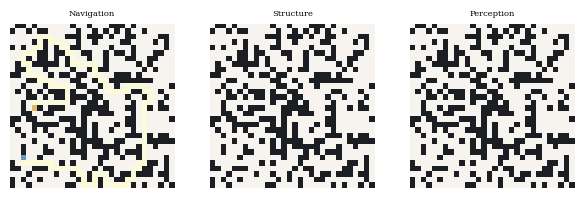

In [7]:
sample = ds[0]
fig = figures.dataset.plot(sample)
_ = plt.show()